<a href="https://colab.research.google.com/github/faisalepty/Sign-Language-CNN/blob/main/train_validatev3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import os
import copy
import torch
import torch.nn as nn
import torch.nn.functional as F

from torchvision import transforms, datasets
from torch.utils.data import ConcatDataset, DataLoader, random_split


In [3]:
train_transforms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),

])

In [4]:
import kagglehub

path = kagglehub.dataset_download("kapillondhe/american-sign-language")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'american-sign-language' dataset.
Path to dataset files: /kaggle/input/american-sign-language


In [5]:
path1 = kagglehub.dataset_download("grassknoted/asl-alphabet")

print("Path to dataset files:", path1)

Using Colab cache for faster access to the 'asl-alphabet' dataset.
Path to dataset files: /kaggle/input/asl-alphabet


In [6]:
path2 = kagglehub.dataset_download("debashishsau/aslamerican-sign-language-aplhabet-dataset")

print("Path to dataset files:", path2)

100%|██████████| 4.20G/4.20G [01:48<00:00, 41.5MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/debashishsau/aslamerican-sign-language-aplhabet-dataset/versions/1


In [7]:
path3 = kagglehub.dataset_download("mrgeislinger/asl-rgb-depth-fingerspelling-spelling-it-out")

print("Path to dataset files:", path3)

Using Colab cache for faster access to the 'asl-rgb-depth-fingerspelling-spelling-it-out' dataset.
Path to dataset files: /kaggle/input/american-sign-language


In [8]:
path4 = kagglehub.dataset_download("ahmedkhanak1995/sign-language-gesture-images-dataset", output_dir="'/data4")

print("Path to dataset files:", path4)

100%|██████████| 191M/191M [00:05<00:00, 37.1MB/s]

Extracting files...


Path to dataset files: /kaggle/input/american-sign-language


In [10]:
path5 = kagglehub.dataset_download("alhasangamalmahmoud/american-sign-language-asl", output_dir="''/data5")

print("Path to dataset files:", path5)

100%|██████████| 2.09G/2.09G [00:54<00:00, 41.4MB/s]

Extracting files...


Path to dataset files: ''/data5


In [19]:
import shutil
import os

# Define the base source and destination directories
base_source_dir = "/content/''/data5/ASL"
base_destination_dir = '/content/data/ASL_Dataset/Train'

# Define the letters to iterate through
letters = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']

for letter in letters:
    # Construct source path with lowercase subfolder name
    source_dir = os.path.join(base_source_dir, letter.upper())
    # Destination path remains with uppercase letter
    destination_dir = os.path.join(base_destination_dir, letter.upper())

    # Create the parent directory for the destination if it doesn't exist
    os.makedirs(os.path.dirname(destination_dir), exist_ok=True)

    try:
        # Use copytree to copy the di
        shutil.copytree(source_dir, destination_dir, dirs_exist_ok=True)
        print(f"Successfully copied '{source_dir}' to '{destination_dir}'")
    except FileNotFoundError:
        print(f"Error: Source directory '{source_dir}' not found. Skipping {letter}")
    except Exception as e:
        print(f"An error occurred during copying '{source_dir}': {e}")


Successfully copied '/content/''/data5/ASL/A' to '/content/data/ASL_Dataset/Train/A'
Successfully copied '/content/''/data5/ASL/B' to '/content/data/ASL_Dataset/Train/B'
Successfully copied '/content/''/data5/ASL/C' to '/content/data/ASL_Dataset/Train/C'
Successfully copied '/content/''/data5/ASL/D' to '/content/data/ASL_Dataset/Train/D'
Successfully copied '/content/''/data5/ASL/E' to '/content/data/ASL_Dataset/Train/E'
Successfully copied '/content/''/data5/ASL/F' to '/content/data/ASL_Dataset/Train/F'
Successfully copied '/content/''/data5/ASL/G' to '/content/data/ASL_Dataset/Train/G'
Successfully copied '/content/''/data5/ASL/H' to '/content/data/ASL_Dataset/Train/H'
Successfully copied '/content/''/data5/ASL/I' to '/content/data/ASL_Dataset/Train/I'
Successfully copied '/content/''/data5/ASL/J' to '/content/data/ASL_Dataset/Train/J'
Successfully copied '/content/''/data5/ASL/K' to '/content/data/ASL_Dataset/Train/K'
Successfully copied '/content/''/data5/ASL/L' to '/content/data/A

In [24]:

import shutil
import os


source_dir = "/content/''/data5/ASL/W_OR_6"
destination_dir = '/content/data/ASL_Dataset/Train/W'

os.makedirs(os.path.dirname(destination_dir), exist_ok=True)

try:
    # Use copytree to copy the di
    shutil.copytree(source_dir, destination_dir, dirs_exist_ok=True)
    print(f"Successfully copied '{source_dir}' to '{destination_dir}'")
except FileNotFoundError:
    print(f"Error: Source directory '{source_dir}' not found. Skipping {letter}")
except Exception as e:
        print(f"An error occurred during copying '{source_dir}': {e}")


Successfully copied '/content/''/data5/ASL/W_OR_6' to '/content/data/ASL_Dataset/Train/W'


In [25]:
import shutil
shutil.rmtree("/content/data/ASL_Dataset/Train/.ipynb_checkpoints", ignore_errors=True)

In [26]:
path = "data"
dataset1 = datasets.ImageFolder("/root/.cache/kagglehub/datasets/debashishsau/aslamerican-sign-language-aplhabet-dataset/versions/1/ASL_Alphabet_Dataset/asl_alphabet_train", transform=val_transforms)
dataset2 = datasets.ImageFolder("/content/data/ASL_Dataset/Train", transform=val_transforms)
dataset3 = datasets.ImageFolder("/kaggle/input/asl-alphabet/asl_alphabet_train/asl_alphabet_train", transform=val_transforms)


dataset = ConcatDataset([dataset1, dataset2, dataset3])

n_total = len(dataset)
n_train = int(0.8*n_total)
n_val = int(n_total - n_train)

train_dataset, val_dataset = random_split(dataset, [n_train, n_val], generator=torch.Generator().manual_seed(42))

In [27]:
print('Classes in dataset1:', dataset1.classes)
print('Classes in dataset2:', dataset2.classes)
print('Classes in dataset3:', dataset3.classes)

Classes in dataset1: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']
Classes in dataset2: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']
Classes in dataset3: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']


In [46]:
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2, pin_memory=True, persistent_workers=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False, num_workers=2, pin_memory=True, persistent_workers=True)

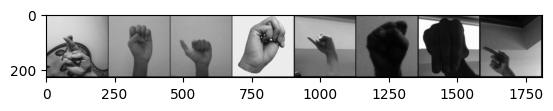

R     E     T     M     J     S     M     G    


In [32]:
import matplotlib.pyplot as plt
import numpy as np
from torchvision.utils import make_grid

def imshow(img):
    img = img  # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# Get a batch of training data
dataiter = iter(train_loader)
images, labels = next(dataiter)

# Show images
imshow(make_grid(images[:8])) # Displaying first 8 images

# Print labels (assuming class names are available)
classes = dataset1.classes
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(8)))

In [ ]:
class LeNet(nn.Module):
    def __init__(self):
        super(LeNet, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=6, kernel_size=5)
        self.conv2 = nn.Conv2d(in_channels=6, out_channels=12, kernel_size=5)
        self.conv3 = nn.Conv2d(12, 16, 3)

        self.fc1 = nn.Linear(in_features=10000, out_features=200)
        self.fc2 = nn.Linear(in_features=200, out_features=84)
        self.fc3 = nn.Linear(in_features=84, out_features=29)
        self.dropout1 = nn.Dropout(0.3)
        self.dropout2 = nn.Dropout(0.5)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = F.relu(self.conv3(x))
        x = F.max_pool2d(x, 2)
        x = x.view(x.size(0), -1)
        x = self.dropout2(x)
        x = F.relu(self.fc1(x))
        x = self.dropout1(x)
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [33]:
class SignLanguageNet(nn.Module):
    def __init__(self):
        super(SignLanguageNet, self).__init__()

        # Block 1
        self.conv1_1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1_1 = nn.BatchNorm2d(32)
        self.conv1_2 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.bn1_2 = nn.BatchNorm2d(32)
        self.pool = nn.MaxPool2d(2, 2)

        # Block 2
        self.conv2_1 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2_1 = nn.BatchNorm2d(64)
        self.conv2_2 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn2_2 = nn.BatchNorm2d(64)

        # Block 3
        self.conv3_1 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3_1 = nn.BatchNorm2d(128)
        self.conv3_2 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.bn3_2 = nn.BatchNorm2d(128)

        # Block 4 (Added for deeper feature extraction)
        self.conv4_1 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4_1 = nn.BatchNorm2d(256)
        self.conv4_2 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        self.bn4_2 = nn.BatchNorm2d(256)

        # Fully connected layers (adjusted for new feature map size and increased capacity)
        # Input image size 224x224. After 4 pooling layers (each halves dimension):
        # 224 -> 112 -> 56 -> 28 -> 14
        # Last conv block has 256 output channels. So, 256 * 14 * 14 = 50176 features
        self.fc1 = nn.Linear(256 * 14 * 14, 1024)
        self.fc2 = nn.Linear(1024, 512)
        self.fc3 = nn.Linear(512, 29) # 29 classes

        self.dropout1 = nn.Dropout(0.3)
        self.dropout2 = nn.Dropout(0.5)

    def forward(self, x):
        # Block 1
        x = F.relu(self.bn1_1(self.conv1_1(x)))
        x = F.relu(self.bn1_2(self.conv1_2(x)))
        x = self.pool(x)

        # Block 2
        x = F.relu(self.bn2_1(self.conv2_1(x)))
        x = F.relu(self.bn2_2(self.conv2_2(x)))
        x = self.pool(x)

        # Block 3
        x = F.relu(self.bn3_1(self.conv3_1(x)))
        x = F.relu(self.bn3_2(self.conv3_2(x)))
        x = self.pool(x)

        # Block 4
        x = F.relu(self.bn4_1(self.conv4_1(x)))
        x = F.relu(self.bn4_2(self.conv4_2(x)))
        x = self.pool(x)

        x = torch.flatten(x, 1)

        x = F.relu(self.fc1(x))
        x = self.dropout1(x)
        x = F.relu(self.fc2(x))
        x = self.dropout2(x)
        x = self.fc3(x)
        return x

In [ ]:
device = ("cuda" if torch.cuda.is_available() else "cpu")
# model = LeNet().to(device=device)
model = SignLanguageNet().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [36]:
from google.colab import drive
drive.mount('/content/drive')

drive_path = '/content/drive/My Drive/Copy of best_model0.pth'

loaded_model = SignLanguageNet()
device = ("cuda" if torch.cuda.is_available() else "cpu")
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(loaded_model.parameters(), lr=0.001)
# Corrected: Pass map_location to torch.load()
loaded_model.load_state_dict(torch.load(drive_path, map_location=torch.device(device)))
loaded_model.eval()

# If you intend to use this loaded_model in the current CPU environment, move it to device
# loaded_model.to(device) # 'device' is currently 'cpu' as seen in kernel state

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


SignLanguageNet(
  (conv1_1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1_1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv1_2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1_2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2_1): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2_1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2_2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2_2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3_1): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3_1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3_2): Conv2d(128, 128, kernel_size=(3, 3

In [37]:
from tqdm import tqdm

In [38]:
def train(model, train_loader):
  model.train()
  running_loss = 0.0
  for images, labels in tqdm(train_loader, desc="Training", leave=True):
      images, labels = images.to(device), labels.to(device)

      optimizer.zero_grad()
      outputs = model(images)
      loss = criterion(outputs, labels)
      loss.backward()
      optimizer.step()

      running_loss += loss.item()
  train_loss = running_loss / len(train_loader)
  return train_loss

In [39]:
def validate(model, val_loader):
  model.eval()
  val_loss = 0.0
  correct = 0

  total = 0
  with torch.no_grad():
      for images, labels in tqdm(val_loader, desc="validating", leave=True):
          images, labels = images.to(device), labels.to(device)
          outputs = model(images)
          loss = criterion(outputs, labels)
          val_loss += loss.item()
          preds = outputs.argmax(dim=1)
          correct += (preds == labels).sum().item()
          total += labels.size(0)
  val_loss /= len(val_loader)
  val_acc = correct / total
  return val_loss, val_acc

In [40]:
import torch
from PIL import Image

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
]
)

def predict(image_path, model, transform, device):
    # 1. Load and transform the image
    img = Image.open(image_path)
    img = img.transpose(Image.FLIP_LEFT_RIGHT)
    img_tensor = transform(img).unsqueeze(0) # Add batch dimension: [1, 3, 128, 128]
    img_tensor = img_tensor.to(device)

    # 2. Set model to evaluation mode
    model.eval()

    with torch.no_grad():
        output = model(img_tensor)
        # Apply softmax to get probabilities
        probabilities = F.softmax(output, dim=1)
        # Get the predicted class index
        conf, predicted = torch.max(probabilities, 1)

    # 3. Map index to label (ImageFolder usually maps alphabetically)
    # class_names = train_dataset.classes -> ['hotdog', 'not-hotdog']
    labels = [
    'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J',
    'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T',
    'U', 'V', 'W', 'X', 'Y', 'Z',
    'del', 'nothing', 'space'
]

    print(f"Prediction: {labels[predicted.item()]} ({conf.item()*100:.2f}%)")

# # Usage:
# image_path = "/kaggle/input/asl-alphabet/asl_alphabet_test/asl_alphabet_test/Y_test.jpg"
# predict(image_path, model, transform, device)

In [ ]:
device = 'cpu'
print(len(dataset1))

# Create a DataLoader for testing using dataset1
test_loader = DataLoader(dataset1, batch_size=1, shuffle=False)

# Assuming loaded_model, device, and validate function are accessible from previous cells
print("Evaluating loaded_model on dataset1:")
test_loss, test_acc = validate(loaded_model, test_loader)

print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")

1815
Evaluating loaded_model on dataset1:


validating: 100%|██████████| 1815/1815 [04:38<00:00,  6.51it/s]

Test Loss: 2.1470, Test Accuracy: 0.3625


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [51]:
loaded_model.to(device)
epochs = 2
best_val_acc = 0.0

for epoch in range(epochs):
    train_loss = train(loaded_model, train_loader)
    val_loss, val_acc = validate(loaded_model, val_loader)

    if val_acc > best_val_acc:
      best_val_acc = val_acc
      torch.save(loaded_model.state_dict(), f"/content/drive/My Drive/model{epoch}.pth")



    print(f"Epoch [{epoch+1}/{epochs}], Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

validating: 100%|██████████| 853/853 [04:27<00:00,  3.19it/s]


Epoch [1/2], Train Loss: 0.1495, Val Loss: 0.0496, Val Acc: 0.9862


validating: 100%|██████████| 853/853 [04:29<00:00,  3.17it/s]


Epoch [2/2], Train Loss: 0.0916, Val Loss: 0.0394, Val Acc: 0.9898


In [49]:
torch.save(loaded_model.state_dict(), f"/content/drive/My Drive/best_model2.pth")


In [50]:
print(f"Epoch [Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

Epoch [Train Loss: 0.3358, Val Loss: 0.0954, Val Acc: 0.9729


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ayuraj/asl-dataset", output_dir="./data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'asl-dataset' dataset.
Path to dataset files: /kaggle/input/asl-dataset


In [ ]:
image_path = "/kaggle/input/asl-dataset/asl_dataset/u/hand1_u_bot_seg_1_cropped.jpeg"

# Redefine transform to match the image size the model was likely trained on (~403x403)
# This is derived from the LeNet's fc1 in_features=35344 and the convolutional layers.
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.RandomHorizontalFlip()
])

predict(image_path, loaded_model, val_transforms, 'cpu')

Prediction: V (22.81%)


In [ ]:
from google.colab import files

# Assuming the file is named 'best_model.pth' and saved in the current directory
files.download('best_model.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print(dataset1.classes)
print(len(dataset))

['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']
482580


In [28]:
print(len(dataset))

545469


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Define the path where you want to save your model in Google Drive
drive_path = '/content/drive/My Drive/best_model.pth'

# Save the model to Google Drive
torch.save(model.state_dict(), drive_path)

print(f"Model saved to Google Drive at: {drive_path}")

Mounted at /content/drive
Model saved to Google Drive at: /content/drive/My Drive/best_model.pth


In [ ]:
from google.colab import drive
import torch

# Mount Google Drive if not already mounted
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# Define the path where you want to save your model in Google Drive
drive_path = '/content/drive/My Drive/best_model.pth'

# Save the model to Google Drive
torch.save(model.state_dict(), drive_path)

print(f"Model saved to Google Drive at: {drive_path}")

MessageError: Error: credential propagation was unsuccessful